# Lab 11 - Information Based Learning
## Decision Trees, Visualization, Regularization, Ensemble Learning

In [15]:
%matplotlib inline
import numpy as np
np.random.seed(42)

In [16]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()

In [17]:
X = iris.data[:, 2:]  # only focus on petal length and width
Y = iris.target
feature_names = iris.feature_names[2:]
print("given:", feature_names, "\npredict whether:", iris.target_names)

given: ['petal length (cm)', 'petal width (cm)'] 
predict whether: ['setosa' 'versicolor' 'virginica']


### Exercise 1.1: Plot the data set

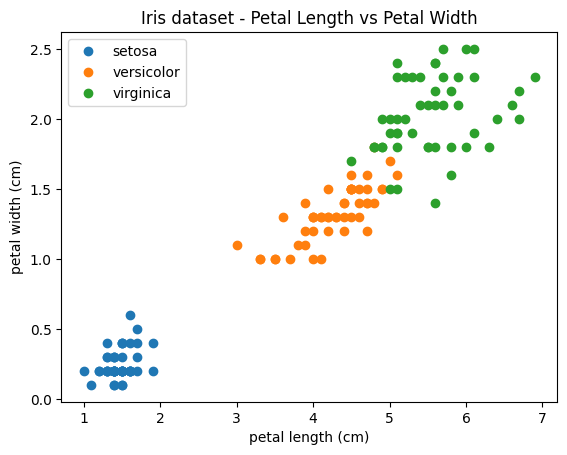

In [18]:
import matplotlib.pyplot as plt

for target_index, target_name in enumerate(iris.target_names):
    plt.plot(X[:, 0][Y == target_index], X[:, 1][Y == target_index], 'o', label=target_name)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.title("Iris dataset - Petal Length vs Petal Width")
plt.show()

In [19]:
tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X, Y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Exercise 1.2: Gini or Entropy

- **Should you use Gini impurity or entropy?** In practice both produce very similar trees and similar
  accuracy most of the time. Gini is the default in scikit-learn and is the more commonly used metric.
- **Which one is faster to compute and why?** Gini impurity is faster to compute because it only
  involves multiplications, whereas entropy requires computing logarithms (log2), which is
  computationally more expensive.
- **Visualize the tree trained above.**
  - *Why does gini impurity decrease in deeper nodes?* As the tree splits the data further, each
    resulting node becomes purer (i.e., contains samples that mostly belong to a single class),
    so the gini impurity (a measure of class mixing) decreases.
  - *Which cases do you see the metric is zero?* Gini = 0 occurs in pure leaf nodes where all
    samples belong to a single class (e.g., the Setosa leaf at depth 1).


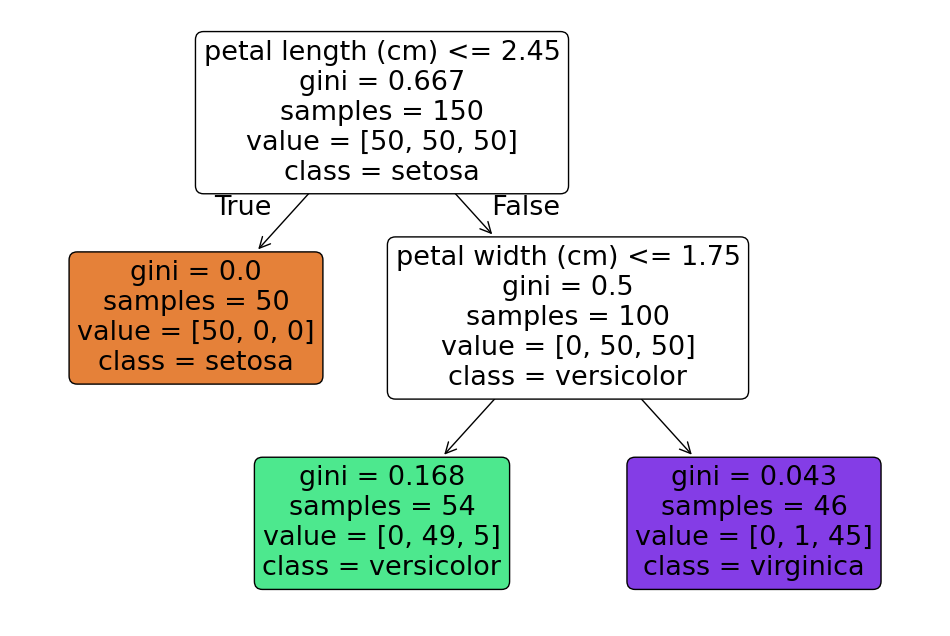

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(tree_clf, feature_names=feature_names, class_names=iris.target_names,
          filled=True, rounded=True)
plt.show()

## 1.2 Visualization (Graphviz)

In [21]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=feature_names,
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

In [22]:
# Make sure graphviz is installed (exclamation mark is for shell commands)
!apt-get install -y graphviz -qq

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


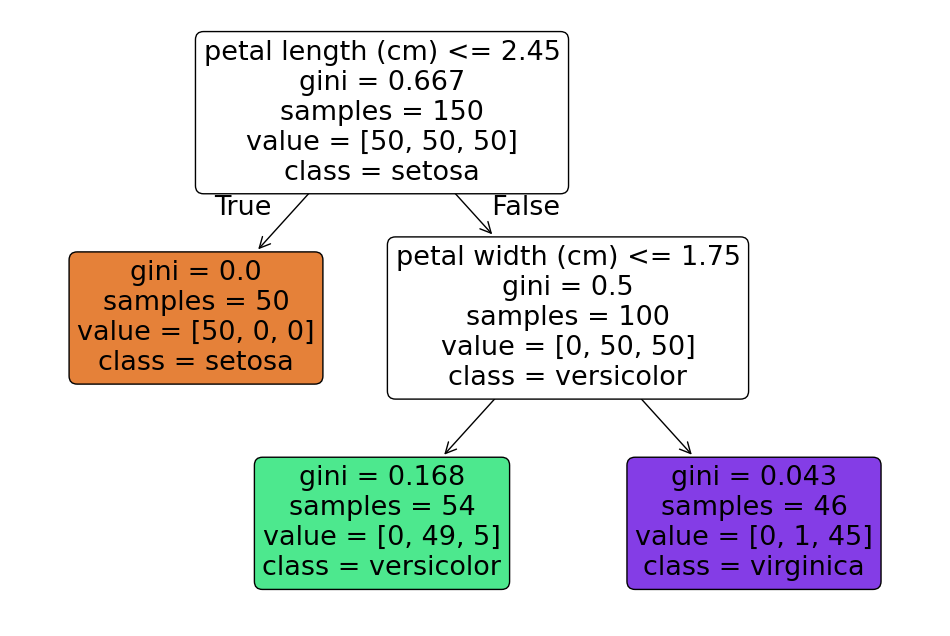

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(tree_clf, feature_names=feature_names, class_names=iris.target_names,
          filled=True, rounded=True)
plt.show()

## 1.3 Plot training data set

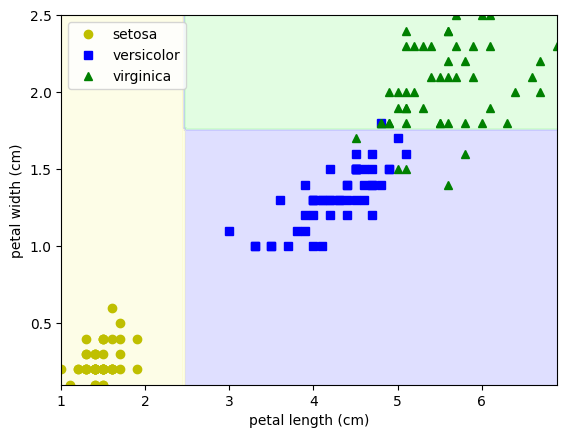

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

CUSTOM_CMAP = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

def plot_decision_boundary(clf, x, y):
    color_map = ["yo", "bs", "g^"]
    for target_index, target_name in enumerate(iris.target_names):
        plt.plot(x[:, 0][y == target_index],
                 x[:, 1][y == target_index],
                 color_map[target_index],
                 label=target_name)

    x1s = np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), 100)
    x2s = np.linspace(np.min(x[:, 1]), np.max(x[:, 1]), 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    x_test = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(x_test).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=CUSTOM_CMAP)

plot_decision_boundary(tree_clf, X, Y)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()

### Exercise 1.3: Plot decision boundaries

1. **Colour correspondence:** Each filled colour region corresponds to a leaf node of the decision
   tree (yellow = Setosa region, blue = Versicolor region, green = Virginica region). The boundary
   lines between colour regions correspond to the split conditions at each internal node.
2. **max_depth experimentation:** Increasing `max_depth` creates more, finer-grained decision
   regions (more splits), which can fit the training data more closely but risks overfitting.
   Decreasing it produces simpler, coarser boundaries (more underfitting). A `max_depth` of 3 is
   often a good trade-off for this dataset - it captures the main structure without overfitting.
3. **Without the helper function:** We could generate a grid of points covering the feature space
   (e.g., using `np.linspace` for each axis combined with `np.meshgrid`), predict the class for
   every point in the grid using `clf.predict()`, and then use `plt.contourf()` to colour the grid
   according to predicted class - which is effectively what the helper function does internally.


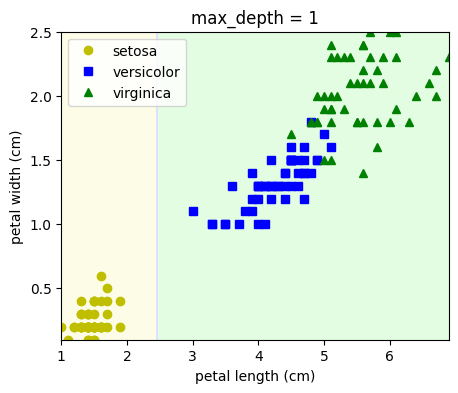

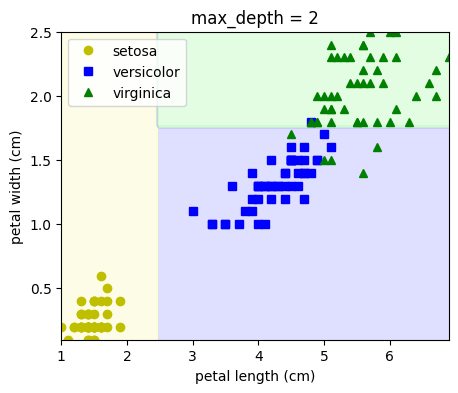

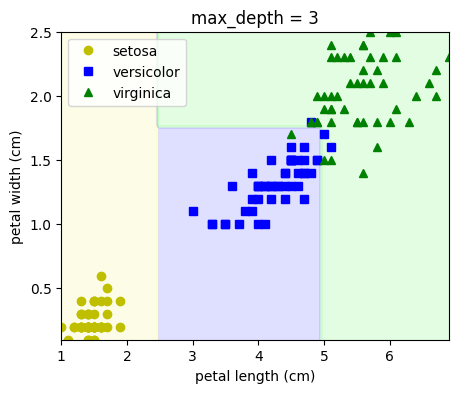

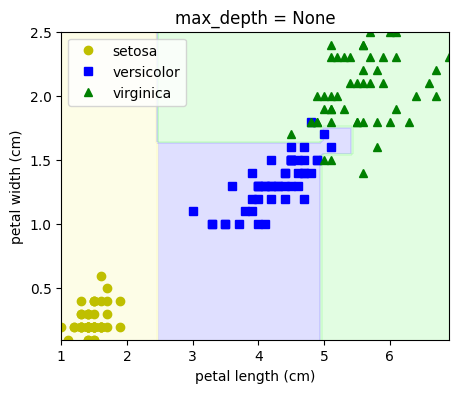

In [25]:
# Try different max_depth values
for depth in [1, 2, 3, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X, Y)
    plt.figure(figsize=(5, 4))
    plot_decision_boundary(clf, X, Y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f"max_depth = {depth}")
    plt.legend()
    plt.show()

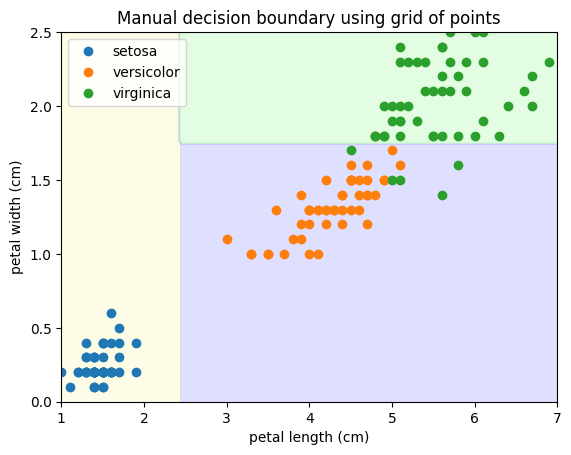

In [26]:
# Tip: try each point in the space (manual decision boundary)
x1s = np.linspace(1, 7, 100)
x2s = np.linspace(0, 2.5, 100)
x1, x2 = np.meshgrid(x1s, x2s)
X_grid = np.c_[x1.ravel(), x2.ravel()]
y_grid_pred = tree_clf.predict(X_grid).reshape(x1.shape)

plt.contourf(x1, x2, y_grid_pred, alpha=0.3, cmap=CUSTOM_CMAP)
for target_index, target_name in enumerate(iris.target_names):
    plt.plot(X[:, 0][Y == target_index], X[:, 1][Y == target_index], 'o', label=target_name)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.title("Manual decision boundary using grid of points")
plt.show()

## 1.4 Estimating Class Probabilities

In [27]:
print(tree_clf.predict_proba([[5, 1.5]]))
print(tree_clf.predict([[5, 1.5]]))

[[0.         0.90740741 0.09259259]]
[1]


## 1.5 Regularization Hyperparameters

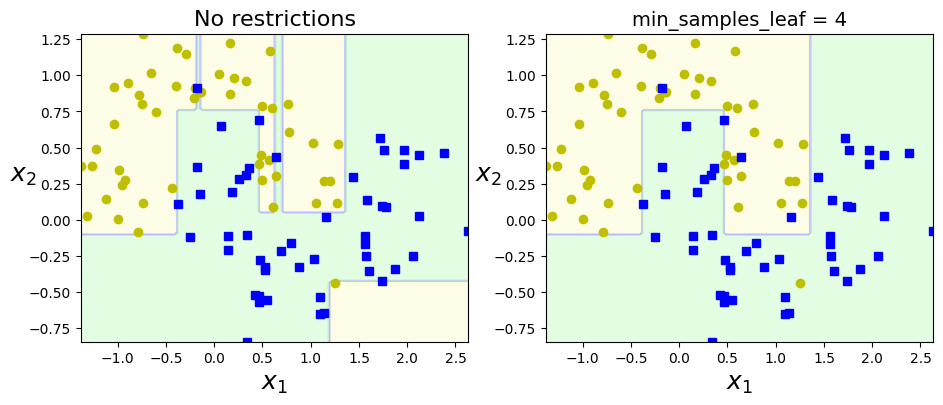

In [28]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)

deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
deep_tree_clf1.fit(Xm, ym)
deep_tree_clf2.fit(Xm, ym)

plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.xlabel(r"$x_1$", fontsize=18)
plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
plot_decision_boundary(deep_tree_clf1, Xm, ym)
plt.title("No restrictions", fontsize=16)

plt.subplot(122)
plt.xlabel(r"$x_1$", fontsize=18)
plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
plot_decision_boundary(deep_tree_clf2, Xm, ym)
plt.title("min_samples_leaf = {}".format(deep_tree_clf2.min_samples_leaf), fontsize=14)
plt.show()

**Observation:** The unrestricted tree (left) creates very intricate boundaries that fit the
training noise (overfitting), while the regularized tree with `min_samples_leaf=4` (right)
produces smoother, more generalizable decision boundaries.

# 2 Regression

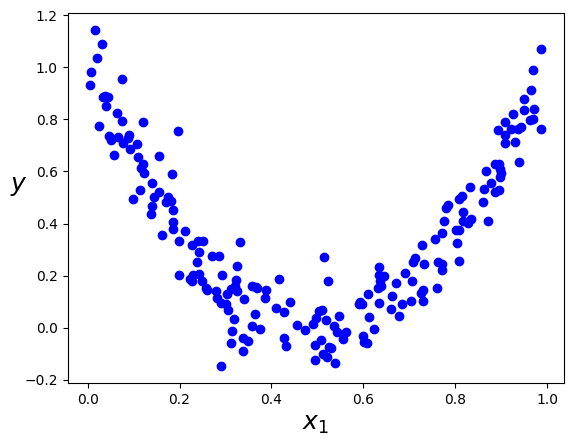

In [29]:
# Quadratic training set + noise
np.random.seed(42)
m = 200
X_reg = np.random.rand(m, 1)
y_reg = 4 * (X_reg - 0.5) ** 2
Y_reg = y_reg + np.random.randn(m, 1) / 10

plt.plot(X_reg, Y_reg, "bo")
plt.xlabel("$x_{1}$", fontsize=18)
plt.ylabel("$y$", fontsize=18, rotation=0)
plt.show()

In [30]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=2)
tree_reg.fit(X_reg, Y_reg)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Exercise 2.1: Visualize the regression tree

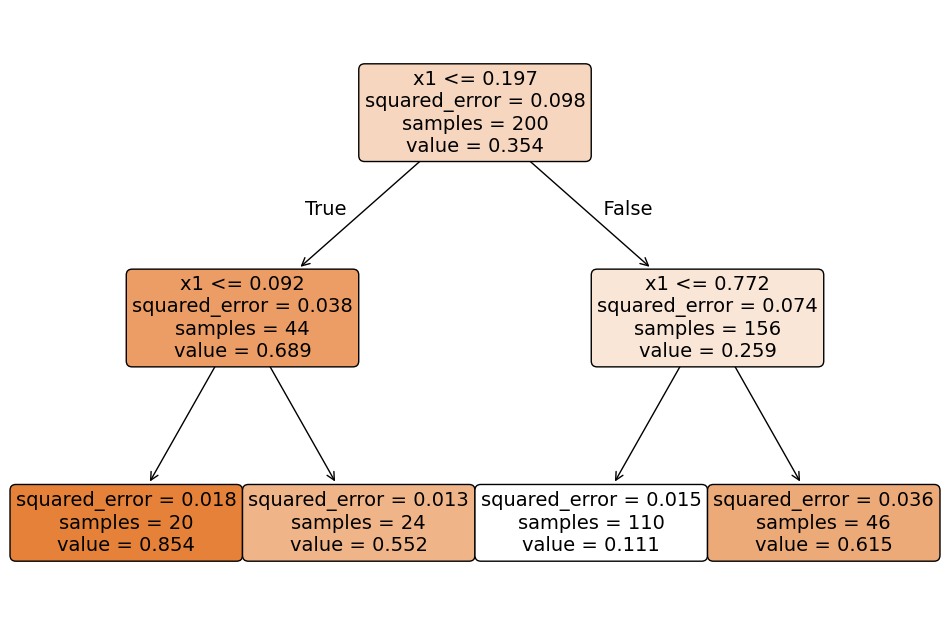

In [31]:
plt.figure(figsize=(12, 8))
plot_tree(tree_reg, feature_names=["x1"], filled=True, rounded=True)
plt.show()

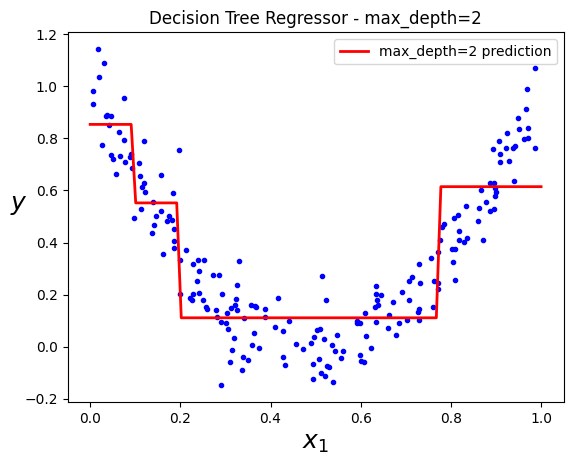

In [32]:
# Plot regression tree predictions
Xs = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred_reg = tree_reg.predict(Xs)

plt.plot(X_reg, Y_reg, "b.")
plt.plot(Xs, y_pred_reg, "r-", linewidth=2, label="max_depth=2 prediction")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", fontsize=18, rotation=0)
plt.legend()
plt.title("Decision Tree Regressor - max_depth=2")
plt.show()

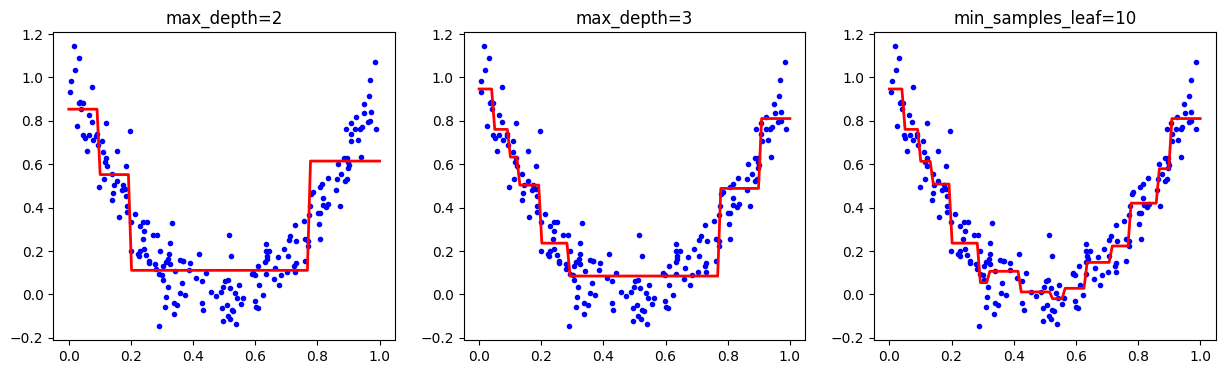

In [33]:
# Compare max_depth=2 vs max_depth=3, also min_samples_leaf=10
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg3 = DecisionTreeRegressor(max_depth=3)
tree_reg_leaf = DecisionTreeRegressor(min_samples_leaf=10)

tree_reg2.fit(X_reg, Y_reg)
tree_reg3.fit(X_reg, Y_reg)
tree_reg_leaf.fit(X_reg, Y_reg)

y_pred2 = tree_reg2.predict(Xs)
y_pred3 = tree_reg3.predict(Xs)
y_pred_leaf = tree_reg_leaf.predict(Xs)

plt.figure(figsize=(15, 4))

plt.subplot(131)
plt.plot(X_reg, Y_reg, "b.")
plt.plot(Xs, y_pred2, "r-", linewidth=2)
plt.title("max_depth=2")

plt.subplot(132)
plt.plot(X_reg, Y_reg, "b.")
plt.plot(Xs, y_pred3, "r-", linewidth=2)
plt.title("max_depth=3")

plt.subplot(133)
plt.plot(X_reg, Y_reg, "b.")
plt.plot(Xs, y_pred_leaf, "r-", linewidth=2)
plt.title("min_samples_leaf=10")

plt.show()

**Comparison:** With `max_depth=2`, the regression tree has only 4 leaves so predictions are
a piecewise-constant step function with few steps - it underfits the curvature of the quadratic data.
With `max_depth=3`, there are up to 8 leaves, giving a finer step approximation that follows the
quadratic shape more closely. With `min_samples_leaf=10`, the tree grows until each leaf has at
least 10 samples, producing many small steps that closely trace the data, balancing flexibility
and overfitting. In all cases, the predicted value in each region is the **average** of the target
values of training samples falling into that region (leaf), which is why the prediction curve looks
like a staircase.

# 3 Ensemble Learning and Random Forests

## 3.1 Voting Classifiers

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, Y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42)

In [35]:
from sklearn.metrics import accuracy_score

def test_clfs(*clfs):
    for clf in clfs:
        clf.fit(X_train, Y_train)
        Y_pred = clf.predict(X_test)
        print(clf.__class__.__name__ + ":", accuracy_score(Y_test, Y_pred))

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(random_state=42, probability=True)

voting_clf = VotingClassifier(estimators=[('lr', log_clf),
                                           ('rf', rnd_clf),
                                           ('svc', svm_clf)],
                               voting='hard')
test_clfs(log_clf, rnd_clf, svm_clf, voting_clf)

LogisticRegression: 0.864
RandomForestClassifier: 0.896
SVC: 0.896
VotingClassifier: 0.912


### Exercise 3.1: Which voting to pick?

In [37]:
voting_clf_soft = VotingClassifier(estimators=[('lr', log_clf),
                                                ('rf', rnd_clf),
                                                ('svc', svm_clf)],
                                    voting='soft')
test_clfs(voting_clf_soft)

VotingClassifier: 0.92


**Answer:** Soft voting usually performs slightly better than hard voting because it takes
into account the confidence (predicted probability) of each classifier, not just its final class
label. A classifier that is very confident about a correct prediction can outweigh classifiers
that are barely confident about an incorrect one. Hard voting treats every vote equally regardless
of confidence, so it can be swayed by classifiers that are uncertain but still cast a vote. In
general, soft voting is preferred when all classifiers can output well-calibrated probabilities
(`predict_proba`).

## 3.2 Bagging & Pasting

Bagging Classifier
0.904
Decision Tree Classifier
0.856


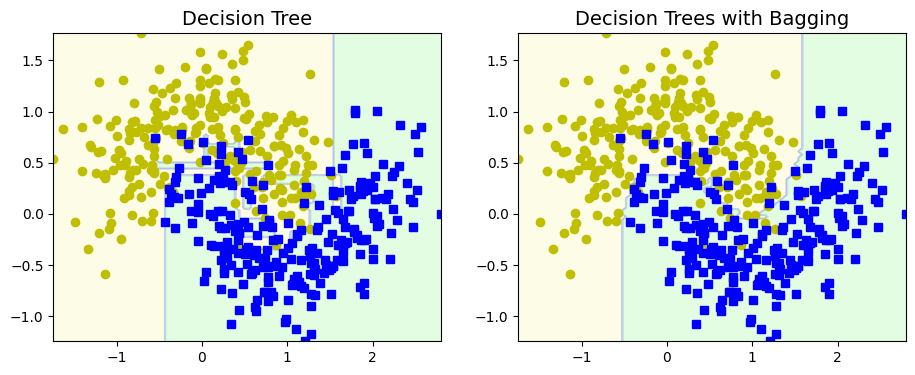

In [42]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree_clf2 = DecisionTreeClassifier(random_state=42)

bag_clf = BaggingClassifier(tree_clf2,
                             n_estimators=500,
                             max_samples=100,
                             bootstrap=True,
                             n_jobs=-1,
                             random_state=42)

bag_clf.fit(X_train, Y_train)
tree_clf2.fit(X_train, Y_train)

Y_pred_bag = bag_clf.predict(X_test)
Y_pred_tree = tree_clf2.predict(X_test)

from sklearn.metrics import accuracy_score
print("Bagging Classifier")
print(accuracy_score(Y_test, Y_pred_bag))
print("Decision Tree Classifier")
print(accuracy_score(Y_test, Y_pred_tree))

plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_decision_boundary(tree_clf2, X, Y)
plt.title("Decision Tree", fontsize=14)
plt.subplot(122)
plot_decision_boundary(bag_clf, X, Y)
plt.title("Decision Trees with Bagging", fontsize=14)
plt.show()

### 3.2 Exercise: Bagging or Pasting

1. **Difference:** Bagging samples subsets **with replacement** (bootstrapping) - the same instance
   can appear multiple times in a single predictor's training subset, and removed instances are
   still available for other predictors. Pasting samples subsets **without replacement** - once an
   instance is selected for a subset, it cannot be selected again for that same subset.
2. **When to use which:** Bagging generally performs better because the extra randomness introduced
   by sampling with replacement increases diversity among predictors, which reduces the variance of
   the ensemble (at the cost of slightly higher bias). Bagging is therefore usually preferred,
   especially when the dataset is small to moderate in size. Pasting can be more appropriate for
   very large datasets where sampling without replacement still gives each predictor enough unique
   data, and where you want to avoid the (small) extra variance bagging introduces from duplicate
   samples.


# 4 Gradient Boosting

### Exercise 4.1: Implement, Plot and Compare

In [39]:
from sklearn.tree import DecisionTreeRegressor

# Quadratic training set
np.random.seed(42)
m = 200
X_gb = np.random.rand(m, 1) - 0.5
y_gb = 3 * X_gb[:, 0] ** 2 + 0.05 * np.random.randn(m)

# 1. Train 3 sequential predictors on residuals
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X_gb, y_gb)

y2 = y_gb - tree_reg1.predict(X_gb)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X_gb, y2)

y3 = y2 - tree_reg2.predict(X_gb)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X_gb, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


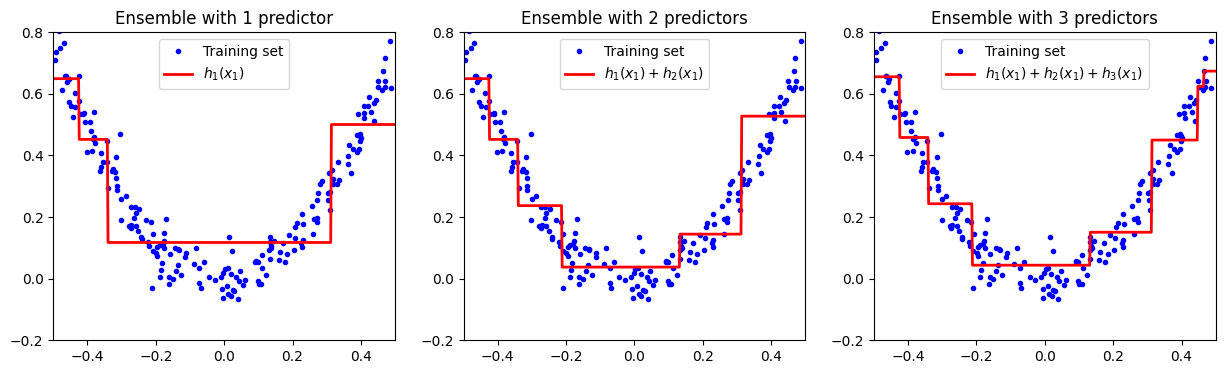

In [40]:
def plot_predictions(regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center")
    plt.axis(axes)

plt.figure(figsize=(15, 4))

plt.subplot(131)
plot_predictions([tree_reg1], X_gb, y_gb, axes=[-0.5, 0.5, -0.2, 0.8],
                  label="$h_1(x_1)$", data_label="Training set")
plt.title("Ensemble with 1 predictor")

plt.subplot(132)
plot_predictions([tree_reg1, tree_reg2], X_gb, y_gb, axes=[-0.5, 0.5, -0.2, 0.8],
                  label="$h_1(x_1) + h_2(x_1)$", data_label="Training set")
plt.title("Ensemble with 2 predictors")

plt.subplot(133)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X_gb, y_gb, axes=[-0.5, 0.5, -0.2, 0.8],
                  label="$h_1(x_1) + h_2(x_1) + h_3(x_1)$", data_label="Training set")
plt.title("Ensemble with 3 predictors")

plt.show()

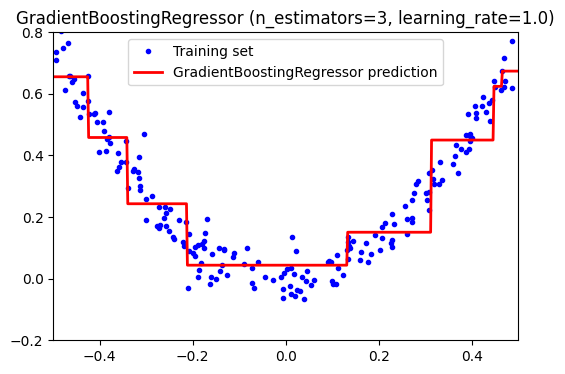

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
gbrt.fit(X_gb, y_gb)

plt.figure(figsize=(6, 4))
plot_predictions([gbrt], X_gb, y_gb, axes=[-0.5, 0.5, -0.2, 0.8],
                  label="GradientBoostingRegressor prediction", data_label="Training set")
plt.title("GradientBoostingRegressor (n_estimators=3, learning_rate=1.0)")
plt.show()

**4. Is this boosting technique scalable in practice?**

The manual implementation (training each tree sequentially on the residuals of the previous one,
and summing all predictions) produces results that closely match scikit-learn's
`GradientBoostingRegressor` with the same hyperparameters - confirming the manual implementation
is correct.

In terms of scalability: Gradient Boosting is **sequential by nature** (each tree depends on the
errors of the previous one), so unlike Random Forests, the trees cannot be trained in parallel.
This makes it slower to train on very large datasets. However, it is still widely used in practice
because: it often achieves higher accuracy than bagging-based ensembles, and optimized
implementations (e.g., XGBoost, LightGBM, CatBoost) use techniques like histogram-based binning
and approximate split finding to scale gradient boosting efficiently to large datasets, including
GPU acceleration. So while it's less parallelizable than Random Forests, with the right
implementation gradient boosting scales well and is heavily used in industry and competitions.


## RECAP

At this point, we demonstrated:
- training and visualizing various models from Decision Trees and Ensemble Learning
- details about some hyperparameters and how to regularize the models
- different training methods for ensemble learning (voting, bagging/pasting)
- how a boosting technique works and its properties
